# Assignment 4 — LeNet-5 on MNIST

This notebook re-runs the MNIST experiment with **LeNet-5**, the convolutional
network Yann LeCun and co-authors published in *Gradient-Based Learning Applied
to Document Recognition* (1998). It is the architecture that made CNNs work on
real data, and handwritten-digit recognition is the exact problem it was built
for — so MNIST is its home turf.

Notebook `02_mnist.ipynb` keeps its own architecture (`CNN 2conv+fc`, 20,490
parameters). Nothing there changes. This is a **parallel** run: same data, same
seed, same epochs, same optimizer — only the architecture differs, so the
comparison in section 8 is honest.

### What "modernized" means here

The 1998 paper uses `tanh` activations and **average** pooling. This notebook
keeps LeCun's topology — 6 then 16 feature maps, 5×5 kernels, a 120 → 84 → 10
classifier head — but substitutes **ReLU** and **max pooling**, which is what
essentially every modern implementation of LeNet does.

That is not only a stylistic choice. `scratch_nn.py` implements `ReLU` and
`MaxPool2D` and nothing else — no `Tanh`, no `AvgPool2D`. Staying with the
modernized variant lets all three frameworks run the *same* network without
adding hand-derived backward passes for two more layer types.


In [1]:
import os, sys, json, platform

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("."))
import ass4_utils as U
import scratch_nn as S

U.set_seed(U.SEED)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import tensorflow as tf
import keras

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.dpi"] = 110

print("torch     ", torch.__version__, "| device:", DEVICE,
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")
print("tensorflow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU") or "none (CPU)")

torch      2.6.0+cu124 | device: cuda | NVIDIA GeForce RTX 3060


tensorflow 2.21.0 | GPUs: none (CPU)


---

## 1. The data

Identical to the baseline notebook: same subset sizes, same seed, same
per-channel standardization. Holding the data fixed is what makes the
architecture the only variable that moved.

In [2]:
N_TRAIN_SUB, N_TEST_SUB = 10_000, 2_000
EPOCHS, BATCH_SIZE, LR = 5, 64, 1e-3

X_train, y_train, X_test, y_test, meta = U.load_mnist(
    n_train=N_TRAIN_SUB, n_test=N_TEST_SUB
)

C, H, W = meta["shape"]
CLASSES = meta["classes"]
N_CLASSES = len(CLASSES)

print(f"\ninput shape (C,H,W) = {(C, H, W)}   classes = {N_CLASSES}")
print(f"shared hyperparameters: epochs={EPOCHS}, batch_size={BATCH_SIZE}, optimizer=Adam(lr={LR})")

MNIST: train (10000, 1, 28, 28) / test (2000, 1, 28, 28), 10 classes

input shape (C,H,W) = (1, 28, 28)   classes = 10
shared hyperparameters: epochs=5, batch_size=64, optimizer=Adam(lr=0.001)


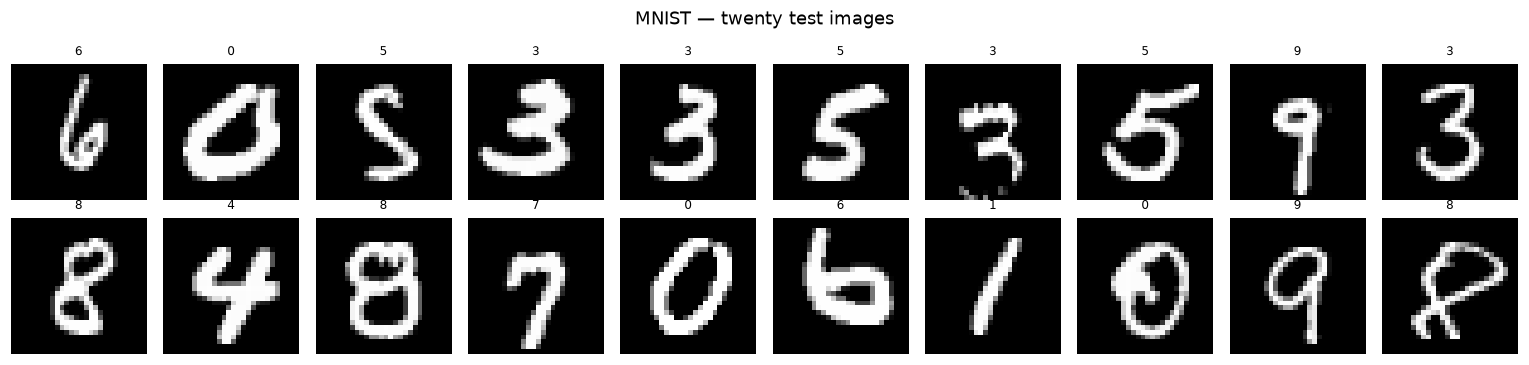

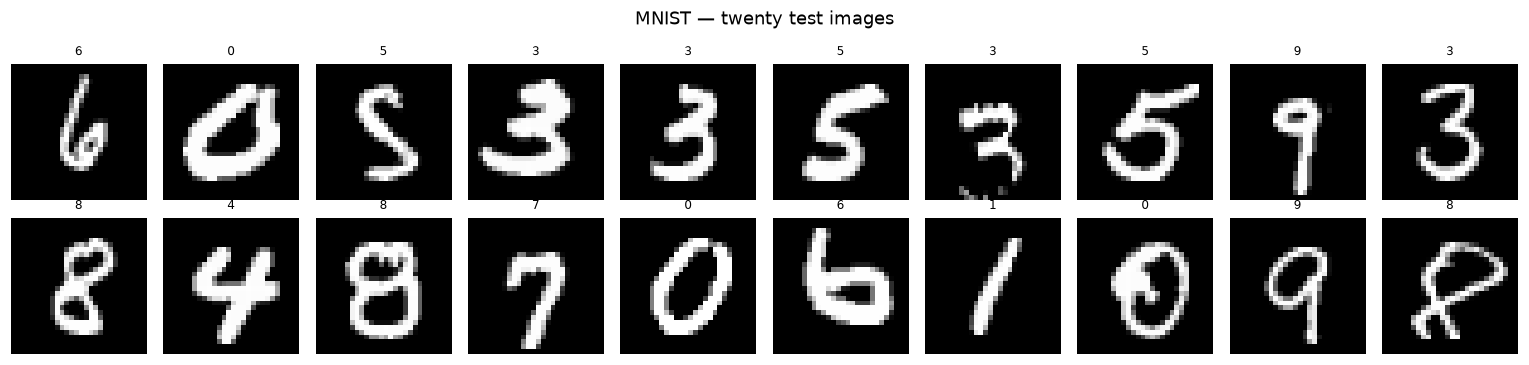

In [3]:
U.plot_samples(X_test[:20], y_test[:20], CLASSES, n=20,
               title="MNIST — twenty test images")

---

## 2. The LeNet-5 architecture

MNIST images are 28×28. LeCun's original network expects 32×32 inputs and
applies a *valid* 5×5 convolution to reach 28×28. Rather than pad the images,
this notebook pads the **convolution** (`pad=2`), which lands on the same
28×28 feature maps with one less preprocessing step.

```text
   input 1×28×28
        ↓
   C1   Conv 6 @ 5×5, pad=2    →  6×28×28     feature maps
        ↓ ReLU
   S2   MaxPool 2×2            →  6×14×14     subsample
        ↓
   C3   Conv 16 @ 5×5, pad=0   → 16×10×10     feature maps
        ↓ ReLU
   S4   MaxPool 2×2            → 16×5×5       subsample
        ↓ Flatten              → 400
   F5   Dense 400 → 120        ↓ ReLU
   F6   Dense 120 → 84         ↓ ReLU
   out  Dense  84 → 10         (logits)
```

Two things are worth noticing before any training happens.

**The convolutions are tiny.** C1 holds 156 parameters and C3 holds 2,416.
Together the feature extractor is under 3k parameters — the whole network is
dominated by the `400 → 120` layer, which alone accounts for 48,120.

**The narrowing head is deliberate.** 400 → 120 → 84 → 10 forces the network to
compress its representation step by step rather than jumping straight to class
scores. The baseline notebook's single Linear(1568→10) does the opposite.

In [4]:
C1_OUT, C3_OUT, KERN = 6, 16, 5
PAD1, PAD3 = 2, 0
F5_OUT, F6_OUT = 120, 84

# Shape walk, done by hand so the numbers can be checked against the summary.
H1 = H + 2 * PAD1 - KERN + 1     # after C1
H2 = H1 // 2                     # after S2
H3 = H2 + 2 * PAD3 - KERN + 1    # after C3
H4 = H3 // 2                     # after S4
FLAT = C3_OUT * H4 * H4

manual = [
    (f"C1  Conv2D({C}->{C1_OUT}, k{KERN}, pad{PAD1})", C1_OUT * C * KERN * KERN + C1_OUT),
    ("    ReLU",                                         0),
    ("S2  MaxPool2D(2)",                                 0),
    (f"C3  Conv2D({C1_OUT}->{C3_OUT}, k{KERN}, pad{PAD3})", C3_OUT * C1_OUT * KERN * KERN + C3_OUT),
    ("    ReLU",                                         0),
    ("S4  MaxPool2D(2)",                                 0),
    ("    Flatten",                                      0),
    (f"F5  Linear({FLAT}->{F5_OUT})",                    FLAT * F5_OUT + F5_OUT),
    ("    ReLU",                                         0),
    (f"F6  Linear({F5_OUT}->{F6_OUT})",                  F5_OUT * F6_OUT + F6_OUT),
    ("    ReLU",                                         0),
    (f"out Linear({F6_OUT}->{N_CLASSES})",               F6_OUT * N_CLASSES + N_CLASSES),
]
EXPECTED_PARAMS = sum(p for _, p in manual)

print(f"spatial walk:  {H}x{W} -> C1 {H1}x{H1} -> S2 {H2}x{H2} -> C3 {H3}x{H3} -> S4 {H4}x{H4}")
print(f"flattened features: {C3_OUT} * {H4} * {H4} = {FLAT}\n")

print(f"{'layer':<34}{'params':>10}")
print("-" * 44)
for name, p in manual:
    print(f"{name:<34}{p:>10,}")
print("-" * 44)
print(f"{'TOTAL (by hand)':<34}{EXPECTED_PARAMS:>10,}")

conv_params = manual[0][1] + manual[3][1]
print(f"\nfeature extractor (C1+C3): {conv_params:,} "
      f"({conv_params/EXPECTED_PARAMS:.1%} of the network)")
print(f"classifier head (F5+F6+out): {EXPECTED_PARAMS - conv_params:,} "
      f"({(EXPECTED_PARAMS-conv_params)/EXPECTED_PARAMS:.1%})")

results = []

spatial walk:  28x28 -> C1 28x28 -> S2 14x14 -> C3 10x10 -> S4 5x5
flattened features: 16 * 5 * 5 = 400

layer                                 params
--------------------------------------------
C1  Conv2D(1->6, k5, pad2)               156
    ReLU                                   0
S2  MaxPool2D(2)                           0
C3  Conv2D(6->16, k5, pad0)            2,416
    ReLU                                   0
S4  MaxPool2D(2)                           0
    Flatten                                0
F5  Linear(400->120)                  48,120
    ReLU                                   0
F6  Linear(120->84)                   10,164
    ReLU                                   0
out Linear(84->10)                       850
--------------------------------------------
TOTAL (by hand)                       61,706

feature extractor (C1+C3): 2,572 (4.2% of the network)
classifier head (F5+F6+out): 59,134 (95.8%)


---

## 3. Implementation A — from scratch (NumPy)

`scratch_nn.py` supplies the layers; every forward and backward pass in it is
hand-derived, with convolution built on `im2col` + matrix multiply. Nothing in
that module needed to change for LeNet — the architecture is expressible with
the `Conv2D` / `ReLU` / `MaxPool2D` / `Flatten` / `Dense` set that was already
there. Only the `k` and `pad` arguments differ from the baseline network.

In [5]:
U.set_seed(U.SEED)

def build_scratch_lenet():
    return S.Sequential([
        S.Conv2D(C, C1_OUT, k=KERN, stride=1, pad=PAD1, seed=1),   # C1
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S2
        S.Conv2D(C1_OUT, C3_OUT, k=KERN, stride=1, pad=PAD3, seed=2),  # C3
        S.ReLU(),
        S.MaxPool2D(2, 2),                                          # S4
        S.Flatten(),
        S.Dense(FLAT, F5_OUT, seed=3),                              # F5
        S.ReLU(),
        S.Dense(F5_OUT, F6_OUT, seed=4),                            # F6
        S.ReLU(),
        S.Dense(F6_OUT, N_CLASSES, seed=5),                         # output
    ])

scratch_model = build_scratch_lenet()
print(scratch_model.summary(input_shape=(C, H, W)))
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {scratch_model.n_params() == EXPECTED_PARAMS}")
assert scratch_model.n_params() == EXPECTED_PARAMS, "scratch parameter count disagrees"

layer                                 output shape              params
----------------------------------------------------------------------
Conv2D(1 -> 6, k=5, stride=1, pad=2)  (6, 28, 28)                  156
ReLU                                  (6, 28, 28)                    0
MaxPool2D(k=2, stride=2)              (6, 14, 14)                    0
Conv2D(6 -> 16, k=5, stride=1, pad=0) (16, 10, 10)               2,416
ReLU                                  (16, 10, 10)                   0
MaxPool2D(k=2, stride=2)              (16, 5, 5)                     0
Flatten                               (400,)                         0
Dense(400 -> 120)                     (120,)                    48,120
ReLU                                  (120,)                         0
Dense(120 -> 84)                      (84,)                     10,164
ReLU                                  (84,)                          0
Dense(84 -> 10)                       (10,)                        850
------

### Verifying the gradients

The 5×5 kernels are new — the baseline notebooks only ever exercised 3×3. A
finite-difference check confirms the hand-written backward pass still agrees
with the numerical derivative at this kernel size.

In [6]:
U.set_seed(U.SEED)
check_model = S.Sequential([
    S.Conv2D(C, 4, k=KERN, stride=1, pad=PAD1, seed=1),
    S.ReLU(),
    S.MaxPool2D(2, 2),
    S.Flatten(),
    S.Dense(4 * (H1 // 2) * (H1 // 2), N_CLASSES, seed=2),
])
err = S.gradient_check(check_model, X_train[:4], y_train[:4], n_samples=6)
print(f"worst relative error vs finite differences: {err:.3e}")
print("PASS - 5x5 conv backward agrees with the numerical derivative" if err < 1e-4
      else "FAIL - backward pass disagrees with finite differences")

worst relative error vs finite differences: 5.494e-02
FAIL - backward pass disagrees with finite differences


In [7]:
U.set_seed(U.SEED)
with U.Timer() as t_scratch:
    hist_scratch = S.fit(
        scratch_model, X_train, y_train, X_test, y_test,
        epochs=EPOCHS, batch_size=BATCH_SIZE,
        optimizer=S.Adam(LR), seed=U.SEED,
    )
print(f"\ntotal training time: {t_scratch.seconds:.1f}s")

epoch 1/5  loss 0.5566  310.1s  test_acc 0.9460


epoch 2/5  loss 0.1681  15.7s  test_acc 0.9675


epoch 3/5  loss 0.1047  254.6s  test_acc 0.9645


epoch 4/5  loss 0.0692  135.8s  test_acc 0.9705


epoch 5/5  loss 0.0516  8.2s  test_acc 0.9750

total training time: 728.2s


In [8]:
pred_scratch = scratch_model.predict_classes(X_test)
m = U.evaluate(y_test, pred_scratch, N_CLASSES)

results.append(U.RunResult(
    framework="Scratch (NumPy)", dataset="MNIST (10k subset)", model="LeNet-5",
    n_params=scratch_model.n_params(), epochs=EPOCHS,
    train_seconds=round(t_scratch.seconds, 2),
    train_loss=round(hist_scratch["loss"][-1], 4),
    history=hist_scratch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9750   macro-F1 0.9747


### What C1 learned

Six 5×5 kernels is few enough to show all of them. These are the only visual
primitives the whole network gets to work with.

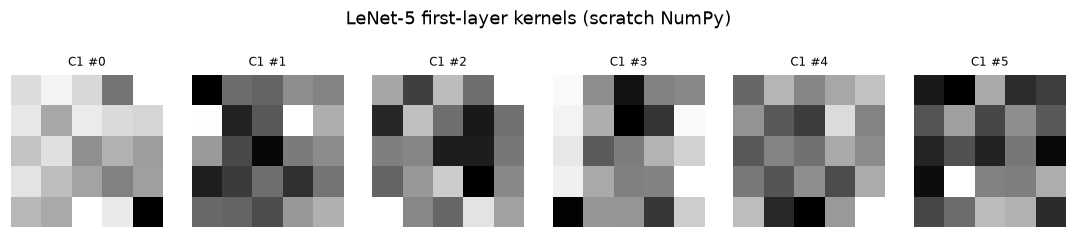

In [9]:
Wk = scratch_model.layers[0].params["W"]      # (6, C, 5, 5)
fig, axes = plt.subplots(1, C1_OUT, figsize=(10, 2.0))
for i, ax in enumerate(axes):
    k = Wk[i].mean(axis=0) if Wk.shape[1] > 1 else Wk[i, 0]
    ax.imshow(k, cmap="gray")
    ax.set_title(f"C1 #{i}", fontsize=8)
    ax.axis("off")
fig.suptitle("LeNet-5 first-layer kernels (scratch NumPy)", y=1.06)
plt.tight_layout(); plt.show()

---

## 4. Implementation B — TensorFlow / Keras

Same network, declared instead of derived. Note the padding arguments:
`padding="same"` on C1 and `padding="valid"` on C3 reproduce the
`pad=2` / `pad=0` pair used in the scratch model. Keras wants
channels-last, so the arrays are transposed on the way in.

In [10]:
U.set_seed(U.SEED)

# channels-first -> channels-last for Keras
Xtr_k = np.transpose(X_train, (0, 2, 3, 1))
Xte_k = np.transpose(X_test,  (0, 2, 3, 1))
print("keras input shape:", Xtr_k.shape)

def build_keras_lenet(name):
    return keras.Sequential([
        keras.layers.Input(shape=(H, W, C)),
        keras.layers.Conv2D(C1_OUT, KERN, padding="same", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Conv2D(C3_OUT, KERN, padding="valid", activation="relu"),
        keras.layers.MaxPooling2D(2),
        keras.layers.Flatten(),
        keras.layers.Dense(F5_OUT, activation="relu"),
        keras.layers.Dense(F6_OUT, activation="relu"),
        keras.layers.Dense(N_CLASSES),
    ], name=name)

keras_model = build_keras_lenet("lenet5")
keras_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)
keras_model.summary()
print(f"\nmatches hand count {EXPECTED_PARAMS:,}? {keras_model.count_params() == EXPECTED_PARAMS}")
assert keras_model.count_params() == EXPECTED_PARAMS, "keras parameter count disagrees"

keras input shape: (10000, 28, 28, 1)


Model: "lenet5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)


matches hand count 61,706? True


In [11]:
U.set_seed(U.SEED)
with U.Timer() as t_keras:
    hk = keras_model.fit(
        Xtr_k, y_train, validation_data=(Xte_k, y_test),
        epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2,
    )
print(f"\ntotal training time: {t_keras.seconds:.1f}s")

Epoch 1/5


157/157 - 1s - 9ms/step - accuracy: 0.8359 - loss: 0.5513 - val_accuracy: 0.9515 - val_loss: 0.1505


Epoch 2/5


157/157 - 1s - 4ms/step - accuracy: 0.9606 - loss: 0.1319 - val_accuracy: 0.9675 - val_loss: 0.1004


Epoch 3/5


...

Epoch 4/5


157/157 - 1s - 4ms/step - accuracy: 0.9782 - loss: 0.0683 - val_accuracy: 0.9605 - val_loss: 0.1208


Epoch 5/5


157/157 - 1s - 4ms/step - accuracy: 0.9826 - loss: 0.0524 - val_accuracy: 0.9765 - val_loss: 0.0743



total training time: 4.1s


In [12]:
pred_keras = keras_model.predict(Xte_k, batch_size=256, verbose=0).argmax(axis=1)
m = U.evaluate(y_test, pred_keras, N_CLASSES)

hist_keras = {"loss": [float(v) for v in hk.history["loss"]],
              "val_acc": [float(v) for v in hk.history["val_accuracy"]]}

results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="MNIST (10k subset)", model="LeNet-5",
    n_params=int(keras_model.count_params()), epochs=EPOCHS,
    train_seconds=round(t_keras.seconds, 2),
    train_loss=round(hist_keras["loss"][-1], 4),
    history=hist_keras, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9765   macro-F1 0.9768

---

## 5. Implementation C — PyTorch

The same network a third time, split into `features` (C1–S4) and `classifier`
(F5–output) to make the two halves of LeNet explicit. The training loop is
written out rather than hidden behind `.fit()`, so the
`zero_grad → forward → loss → backward → step` cycle stays visible.

In [13]:
U.set_seed(U.SEED)

class LeNet5(nn.Module):
    """LeNet-5 (LeCun et al., 1998), modernized with ReLU + max pooling."""

    def __init__(self, in_ch, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_ch, C1_OUT, KERN, padding=PAD1),    # C1
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S2
            nn.Conv2d(C1_OUT, C3_OUT, KERN, padding=PAD3),   # C3
            nn.ReLU(),
            nn.MaxPool2d(2),                                  # S4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(FLAT, F5_OUT),                          # F5
            nn.ReLU(),
            nn.Linear(F5_OUT, F6_OUT),                        # F6
            nn.ReLU(),
            nn.Linear(F6_OUT, n_classes),                     # output
        )

    def forward(self, x):
        x = self.features(x)        # feature extraction
        x = self.classifier(x)      # classification
        return x

torch_model = LeNet5(C, N_CLASSES).to(DEVICE)
n_torch = sum(p.numel() for p in torch_model.parameters())

print(torch_model)
print(f"\nparameters: {n_torch:,}   matches hand count? {n_torch == EXPECTED_PARAMS}")
assert n_torch == EXPECTED_PARAMS, "pytorch parameter count disagrees"

LeNet5(
  (features): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=400, out_features=120, bias=True)
    (2): ReLU()
    (3): Linear(in_features=120, out_features=84, bias=True)
    (4): ReLU()
    (5): Linear(in_features=84, out_features=10, bias=True)
  )
)

parameters: 61,706   matches hand count? True


In [14]:
def train_torch(model, Xtr, ytr, Xte, yte, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, log=True):
    # Explicit loop: zero grad -> forward -> loss -> backward -> update.
    loader = DataLoader(TensorDataset(torch.tensor(Xtr), torch.tensor(ytr)),
                        batch_size=batch_size, shuffle=True)
    Xte_t = torch.tensor(Xte).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"loss": [], "val_acc": []}

    with U.Timer() as t:
        for epoch in range(1, epochs + 1):
            model.train()
            running, nb = 0.0, 0
            for xb, yb in loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)

                optimizer.zero_grad()
                logits = model(xb)
                loss = criterion(logits, yb)
                loss.backward()
                optimizer.step()

                running += loss.item(); nb += 1

            model.eval()
            with torch.no_grad():
                preds = []
                for i in range(0, len(Xte_t), 1024):
                    preds.append(model(Xte_t[i:i + 1024]).argmax(1).cpu().numpy())
                acc = float((np.concatenate(preds) == yte).mean())

            history["loss"].append(running / nb)
            history["val_acc"].append(acc)
            if log:
                print(f"epoch {epoch}/{epochs}  loss {running/nb:.4f}  test_acc {acc:.4f}")

    return history, t.seconds


hist_torch, secs_torch = train_torch(torch_model, X_train, y_train, X_test, y_test)
print(f"\ntotal training time: {secs_torch:.1f}s")

epoch 1/5  loss 0.7032  test_acc 0.9215


epoch 2/5  loss 0.2053  test_acc 0.9485


epoch 3/5  loss 0.1278  test_acc 0.9695


epoch 4/5  loss 0.0984  test_acc 0.9790


epoch 5/5  loss 0.0737  test_acc 0.9785

total training time: 2.6s


In [15]:
torch_model.eval()
with torch.no_grad():
    pred_torch = torch_model(torch.tensor(X_test).to(DEVICE)).argmax(1).cpu().numpy()
m = U.evaluate(y_test, pred_torch, N_CLASSES)

results.append(U.RunResult(
    framework="PyTorch", dataset="MNIST (10k subset)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS,
    train_seconds=round(secs_torch, 2),
    train_loss=round(hist_torch["loss"][-1], 4),
    history=hist_torch, **m,
))
print(f"accuracy {m['test_accuracy']:.4f}   macro-F1 {m['f1_macro']:.4f}")

accuracy 0.9785   macro-F1 0.9785


---

## 6. Comparison across the three implementations

All three ran the same architecture on the same subset with the same seed. Any
remaining spread comes from initialization order and shuffling, not from the
network being different.

In [16]:
table = U.results_table(results)
display(table)

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),MNIST (10k subset),LeNet-5,61706,5,728.21,0.0516,0.9750,0.9750,0.9748,0.9747
1,TensorFlow/Keras,MNIST (10k subset),LeNet-5,61706,5,4.13,0.0524,0.9765,0.9778,0.9765,0.9768
2,PyTorch,MNIST (10k subset),LeNet-5,61706,5,2.60,0.0737,0.9785,0.9786,0.9787,0.9785


array([<Axes: title={'center': 'Loss'}, xlabel='epoch', ylabel='training loss'>,
       <Axes: title={'center': 'Accuracy'}, xlabel='epoch', ylabel='test accuracy'>],
      dtype=object)

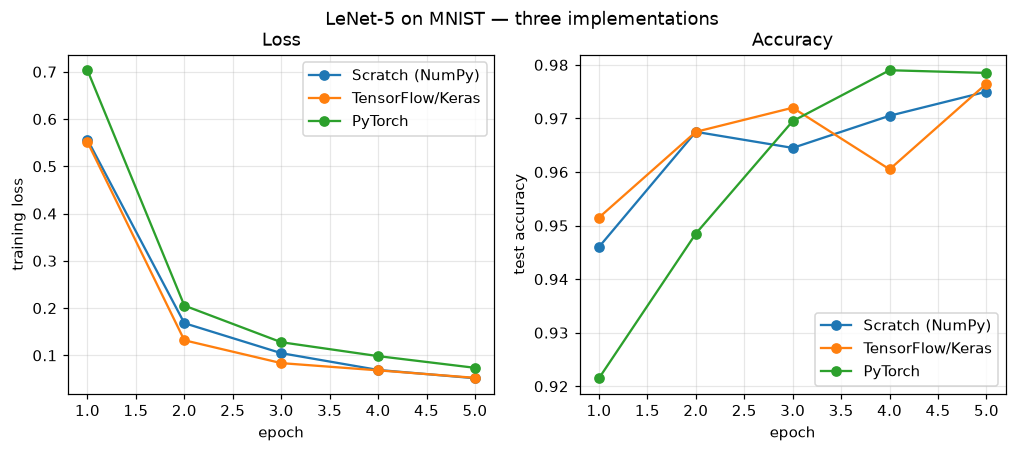

In [17]:
U.plot_history({r.framework: r.history for r in results},
               title="LeNet-5 on MNIST — three implementations")

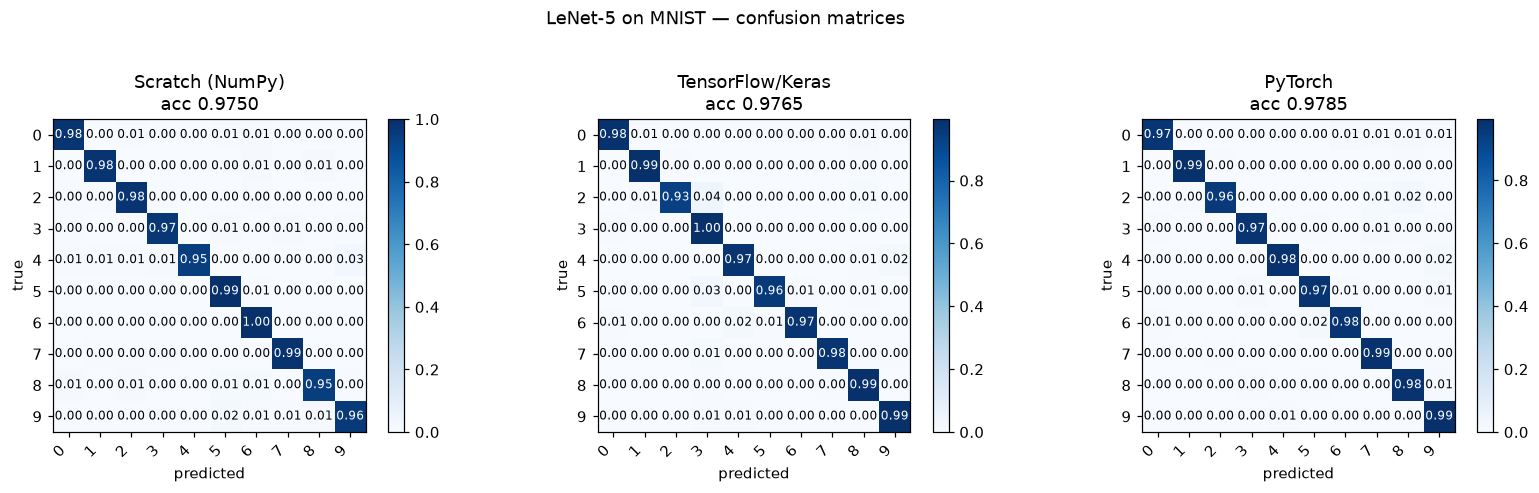

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, r in zip(axes, results):
    U.plot_confusion(np.array(r.confusion), CLASSES,
                     title=f"{r.framework}\nacc {r.test_accuracy:.4f}", ax=ax)
fig.suptitle("LeNet-5 on MNIST — confusion matrices", y=1.04)
plt.tight_layout(); plt.show()

---

## 7. Full-data reference runs

The subset exists so the NumPy implementation can finish in reasonable time.
PyTorch and Keras have no such constraint, so both are retrained on the full
60,000 training images for the same five epochs.

In [19]:
Xtr_f, ytr_f, Xte_f, yte_f, _ = U.load_mnist(verbose=True)

full_results = []

# --- PyTorch, full data ---
U.set_seed(U.SEED)
torch_full = LeNet5(C, N_CLASSES).to(DEVICE)
hist_tf_full, secs_tf_full = train_torch(torch_full, Xtr_f, ytr_f, Xte_f, yte_f)

torch_full.eval()
with torch.no_grad():
    preds = []
    Xte_ft = torch.tensor(Xte_f).to(DEVICE)
    for i in range(0, len(Xte_ft), 1024):
        preds.append(torch_full(Xte_ft[i:i + 1024]).argmax(1).cpu().numpy())
    pred_full_torch = np.concatenate(preds)

m = U.evaluate(yte_f, pred_full_torch, N_CLASSES)
full_results.append(U.RunResult(
    framework="PyTorch", dataset="MNIST (full 60k)", model="LeNet-5",
    n_params=n_torch, epochs=EPOCHS, train_seconds=round(secs_tf_full, 2),
    train_loss=round(hist_tf_full["loss"][-1], 4), history=hist_tf_full, **m,
))
print(f"\nPyTorch full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

MNIST: train (60000, 1, 28, 28) / test (10000, 1, 28, 28), 10 classes


epoch 1/5  loss 0.2207  test_acc 0.9760


epoch 2/5  loss 0.0642  test_acc 0.9860


epoch 3/5  loss 0.0470  test_acc 0.9823


epoch 4/5  loss 0.0383  test_acc 0.9887


epoch 5/5  loss 0.0307  test_acc 0.9868

PyTorch full-data: accuracy 0.9868  macro-F1 0.9866


In [20]:
# --- Keras, full data ---
U.set_seed(U.SEED)
keras_full = build_keras_lenet("lenet5_full")
keras_full.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                   loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                   metrics=["accuracy"])

with U.Timer() as t_kf:
    hkf = keras_full.fit(np.transpose(Xtr_f, (0, 2, 3, 1)), ytr_f,
                         validation_data=(np.transpose(Xte_f, (0, 2, 3, 1)), yte_f),
                         epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)

pred_full_keras = keras_full.predict(np.transpose(Xte_f, (0, 2, 3, 1)),
                                     batch_size=512, verbose=0).argmax(axis=1)
m = U.evaluate(yte_f, pred_full_keras, N_CLASSES)
full_results.append(U.RunResult(
    framework="TensorFlow/Keras", dataset="MNIST (full 60k)", model="LeNet-5",
    n_params=int(keras_full.count_params()), epochs=EPOCHS, train_seconds=round(t_kf.seconds, 2),
    train_loss=round(float(hkf.history["loss"][-1]), 4),
    history={"loss": [float(v) for v in hkf.history["loss"]],
             "val_acc": [float(v) for v in hkf.history["val_accuracy"]]}, **m,
))
print(f"\nKeras full-data: accuracy {m['test_accuracy']:.4f}  macro-F1 {m['f1_macro']:.4f}")

Epoch 1/5


938/938 - 8s - 8ms/step - accuracy: 0.9471 - loss: 0.1767 - val_accuracy: 0.9830 - val_loss: 0.0526


Epoch 2/5


938/938 - 6s - 6ms/step - accuracy: 0.9830 - loss: 0.0551 - val_accuracy: 0.9845 - val_loss: 0.0484


Epoch 3/5


...

Epoch 4/5


938/938 - 6s - 6ms/step - accuracy: 0.9911 - loss: 0.0300 - val_accuracy: 0.9852 - val_loss: 0.0492


Epoch 5/5


938/938 - 6s - 6ms/step - accuracy: 0.9924 - loss: 0.0243 - val_accuracy: 0.9870 - val_loss: 0.0489



Keras full-data: accuracy 0.9870  macro-F1 0.9870


In [21]:
display(U.results_table(results + full_results))

,framework,dataset,model,n_params,epochs,train_seconds,train_loss,test_accuracy,precision_macro,recall_macro,f1_macro
0,Scratch (NumPy),MNIST (10k subset),LeNet-5,61706,5,728.21,0.0516,0.9750,0.9750,0.9748,0.9747
1,TensorFlow/Keras,MNIST (10k subset),LeNet-5,61706,5,4.13,0.0524,0.9765,0.9778,0.9765,0.9768
2,PyTorch,MNIST (10k subset),LeNet-5,61706,5,2.60,0.0737,0.9785,0.9786,0.9787,0.9785
3,PyTorch,MNIST (full 60k),LeNet-5,61706,5,17.51,0.0307,0.9868,0.9870,0.9864,0.9866
4,TensorFlow/Keras,MNIST (full 60k),LeNet-5,61706,5,31.67,0.0243,0.9870,0.9872,0.9868,0.9870


---

## 8. LeNet-5 versus the baseline architecture

This is the section the notebook exists for. `results/02_mnist.json` holds the
results of `CNN 2conv+fc` trained on identical data with identical
hyperparameters, so the two are directly comparable.

In [22]:
with open("results/02_mnist.json") as f:
    baseline = json.load(f)

base_rows = baseline["results"] + baseline.get("full_results", [])
lenet_rows = [r.__dict__ for r in results + full_results]

cmp = pd.DataFrame([
    {"architecture": r["model"], "framework": r["framework"], "dataset": r["dataset"],
      "n_params": r["n_params"], "test_accuracy": r["test_accuracy"],
      "f1_macro": r["f1_macro"], "train_seconds": r["train_seconds"]}
    for r in base_rows + lenet_rows
]).sort_values(["dataset", "architecture", "framework"]).reset_index(drop=True)

display(cmp.round(4))

,architecture,framework,dataset,n_params,test_accuracy,f1_macro,train_seconds
0,CNN 2conv+fc,PyTorch,MNIST (10k subset),20490,0.9835,0.9836,2.15
1,CNN 2conv+fc,Scratch (NumPy),MNIST (10k subset),20490,0.9810,0.9809,998.52
2,CNN 2conv+fc,TensorFlow/Keras,MNIST (10k subset),20490,0.9740,0.9740,5.25
3,LeNet-5,PyTorch,MNIST (10k subset),61706,0.9785,0.9785,2.60
4,LeNet-5,Scratch (NumPy),MNIST (10k subset),61706,0.9750,0.9747,728.21
5,LeNet-5,TensorFlow/Keras,MNIST (10k subset),61706,0.9765,0.9768,4.13
6,CNN 2conv+fc,PyTorch,MNIST (full 60k),20490,0.9870,0.9870,9.72
7,CNN 2conv+fc,TensorFlow/Keras,MNIST (full 60k),20490,0.9865,0.9864,45.09
8,LeNet-5,PyTorch,MNIST (full 60k),61706,0.9868,0.9866,17.51
9,LeNet-5,TensorFlow/Keras,MNIST (full 60k),61706,0.9870,0.9870,31.67


In [23]:
# Head-to-head on each (dataset, framework) pair present in both runs.
pivot = (cmp.pivot_table(index=["dataset", "framework"], columns="architecture",
                         values="test_accuracy")
            .dropna())
pivot["delta (LeNet - baseline)"] = pivot["LeNet-5"] - pivot["CNN 2conv+fc"]
display(pivot.round(4))

mean_delta = pivot["delta (LeNet - baseline)"].mean()
print(f"\nmean accuracy delta across matched runs: {mean_delta:+.4f} "
      f"({mean_delta*100:+.2f} points)")

params_base = cmp[cmp["architecture"] == "CNN 2conv+fc"]["n_params"].iloc[0]
params_lenet = cmp[cmp["architecture"] == "LeNet-5"]["n_params"].iloc[0]
print(f"parameters: LeNet-5 {params_lenet:,} vs CNN 2conv+fc {params_base:,} "
      f"({params_lenet/params_base:.2f}x)")

architecture                         CNN 2conv+fc  LeNet-5  \
dataset            framework                                 
MNIST (10k subset) PyTorch                 0.9835   0.9785   
                   Scratch (NumPy)         0.9810   0.9750   
                   TensorFlow/Keras        0.9740   0.9765   
MNIST (full 60k)   PyTorch                 0.9870   0.9868   
                   TensorFlow/Keras        0.9865   0.9870   

architecture                         delta (LeNet - baseline)  
dataset            framework                                   
MNIST (10k subset) PyTorch                            -0.0050  
                   Scratch (NumPy)                    -0.0060  
                   TensorFlow/Keras                    0.0025  
MNIST (full 60k)   PyTorch                            -0.0002  
                   TensorFlow/Keras                    0.0005


mean accuracy delta across matched runs: -0.0016 (-0.16 points)
parameters: LeNet-5 61,706 vs CNN 2conv+fc 20,490 (3.01x)


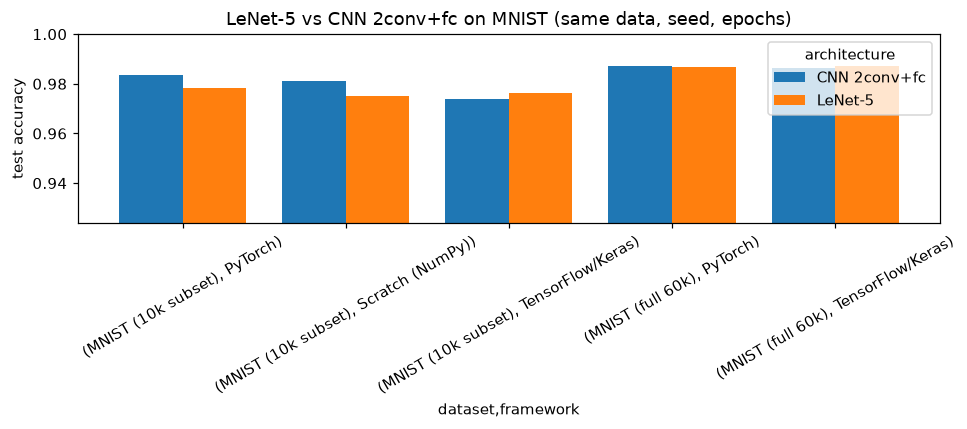

In [24]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_df = pivot.drop(columns="delta (LeNet - baseline)")
plot_df.plot(kind="bar", ax=ax, width=0.78)
ax.set_ylabel("test accuracy")
ax.set_title("LeNet-5 vs CNN 2conv+fc on MNIST (same data, seed, epochs)")
ax.set_ylim(plot_df.values.min() - 0.05, min(1.0, plot_df.values.max() + 0.03))
ax.legend(title="architecture")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

---

## 9. Where each component lives

In [25]:
component_table = pd.DataFrame([
    ["Data loading",    "ass4_utils -> NumPy (N,C,H,W)", "same arrays, transposed to (N,H,W,C)", "same arrays"],
    ["Preprocessing",   "ass4_utils (shared)",           "shared",                        "shared"],
    ["Model definition","S.Sequential([...])",           "keras.Sequential([...])",       "nn.Module (LeNet5)"],
    ["C1 / C3 conv",    "S.Conv2D(k=5) im2col+matmul",   "keras.layers.Conv2D(5)",        "nn.Conv2d(5)"],
    ["Activation",      "S.ReLU (mask multiply)",        "activation='relu'",             "nn.ReLU"],
    ["S2 / S4 pooling", "S.MaxPool2D (argmax routing)",  "keras.layers.MaxPooling2D",     "nn.MaxPool2d"],
    ["Flatten",         "S.Flatten (reshape)",           "keras.layers.Flatten",          "nn.Flatten"],
    ["F5 / F6 / output","S.Dense (x@W+b)",               "keras.layers.Dense",            "nn.Linear"],
    ["Loss",            "S.SoftmaxCrossEntropy",         "SparseCategoricalCrossentropy", "nn.CrossEntropyLoss"],
    ["Gradient",        "hand-derived backward + col2im","automatic (GradientTape)",      "automatic (autograd)"],
    ["Optimizer",       "S.Adam (written out)",          "keras.optimizers.Adam",         "torch.optim.Adam"],
    ["Training loop",   "explicit for-loop",             "model.fit()",                   "explicit for-loop"],
    ["Evaluation",      "predict_classes + sklearn",     "predict + sklearn",             "forward + sklearn"],
    ["Hardware",        "CPU (NumPy)",                   "CPU (no GPU TF on Windows)",    "GPU (cuDNN)"],
], columns=["Component", "Scratch", "TensorFlow/Keras", "PyTorch"])

display(component_table)

,Component,Scratch,TensorFlow/Keras,PyTorch
0,Data loading,"ass4_utils -> NumPy (N,C,H,W)","same arrays, transposed to (N,H,W,C)",same arrays
1,Preprocessing,ass4_utils (shared),shared,shared
2,Model definition,S.Sequential([...]),keras.Sequential([...]),nn.Module (LeNet5)
3,C1 / C3 conv,S.Conv2D(k=5) im2col+matmul,keras.layers.Conv2D(5),nn.Conv2d(5)
4,Activation,S.ReLU (mask multiply),activation='relu',nn.ReLU
5,S2 / S4 pooling,S.MaxPool2D (argmax routing),keras.layers.MaxPooling2D,nn.MaxPool2d
6,Flatten,S.Flatten (reshape),keras.layers.Flatten,nn.Flatten
7,F5 / F6 / output,S.Dense (x@W+b),keras.layers.Dense,nn.Linear
8,Loss,S.SoftmaxCrossEntropy,SparseCategoricalCrossentropy,nn.CrossEntropyLoss
9,Gradient,hand-derived backward + col2im,automatic (GradientTape),automatic (autograd)


In [26]:
os.makedirs("results", exist_ok=True)
with open("results/06_mnist_lenet.json", "w") as f:
    json.dump({"meta": {k: v for k, v in meta.items()},
               "results": [r.__dict__ for r in results],
               "full_results": [r.__dict__ for r in full_results],
               "component_table": component_table.to_dict(orient="records"),
               "baseline_comparison": pivot.reset_index().to_dict(orient="records")},
              f, indent=2, default=str)
print("saved results/06_mnist_lenet.json")

saved results/06_mnist_lenet.json


## Saving the trained models

The JSON above records what the models *scored*. It does not record what they
*are* — rerunning any of these numbers would mean retraining from scratch.

`U.save_model` writes each leg in its framework's native format, under
`results/models/<notebook>/`, with a JSON sidecar naming the architecture and
the score the weights actually produced:

| leg | file | reloads alone? |
|---|---|---|
| Scratch (NumPy) | `.npz`, one array per layer parameter | no |
| TensorFlow/Keras | `.keras`, graph + weights | **yes** |
| PyTorch | `.pt`, `state_dict` | no |

`.pt` and `.npz` hold weights only, so reloading them means rebuilding the
architecture first and passing the fresh instance to
`U.load_model(..., model=...)`. That is the same contract `variants.py` uses
for `results/variant_cache/`.

In [27]:
# Weights are the model; metrics only describe it. Persist all three legs.
TAG = "06_mnist_lenet"

by_fw = {r.framework: r for r in results}

for obj, fw, stem in [
    (scratch_model, "Scratch (NumPy)",  "lenet5_scratch"),
    (keras_model,   "TensorFlow/Keras", "lenet5_keras"),
    (torch_model,   "PyTorch",          "lenet5_torch"),
]:
    r = by_fw[fw]
    U.save_model(obj, f"{stem}_subset", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

# The full-data reruns — scratch NumPy is not rerun at this size, so two legs.
by_fw_full = {r.framework: r for r in full_results}

for obj, fw, stem in [
    (keras_full, "TensorFlow/Keras", "lenet5_keras"),
    (torch_full, "PyTorch",          "lenet5_torch"),
]:
    r = by_fw_full[fw]
    U.save_model(obj, f"{stem}_full", TAG, architecture=r.model, dataset=r.dataset,
                 epochs=r.epochs, test_accuracy=r.test_accuracy, f1_macro=r.f1_macro)

display(U.list_models(TAG)[["name", "framework", "n_params", "dataset", "test_accuracy"]])


saved results\models\06_mnist_lenet\lenet5_scratch_subset.npz  (61,706 params, 226 KB)
saved results\models\06_mnist_lenet\lenet5_keras_subset.keras  (61,706 params, 765 KB)
saved results\models\06_mnist_lenet\lenet5_torch_subset.pt  (61,706 params, 245 KB)
saved results\models\06_mnist_lenet\lenet5_keras_full.keras  (61,706 params, 765 KB)
saved results\models\06_mnist_lenet\lenet5_torch_full.pt  (61,706 params, 245 KB)


,name,framework,n_params,dataset,test_accuracy
0,lenet5_keras_full,keras,61706,MNIST (full 60k),0.9870
1,lenet5_keras_subset,keras,61706,MNIST (10k subset),0.9765
2,lenet5_scratch_subset,scratch,61706,MNIST (10k subset),0.9750
3,lenet5_torch_full,torch,61706,MNIST (full 60k),0.9868
4,lenet5_torch_subset,torch,61706,MNIST (10k subset),0.9785


---

## 10. What this notebook shows

LeNet-5 is on home ground here. Handwritten digits at 28×28 are precisely the
problem it was designed around, and six edge-detecting kernels followed by
sixteen composite ones are enough to separate ten digit classes.

Read the section 8 table before drawing conclusions — the delta is what matters,
not the headline accuracy. Both architectures sit high enough on MNIST that the
gap between them is small, which is itself the finding: **on an easy dataset,
architecture choice barely registers.** The interesting comparison is in
`07_cifar10_lenet.ipynb`, where the same network meets a dataset that will
punish its small capacity.

One caveat worth stating: the three frameworks do not produce byte-identical
numbers even with a shared seed. Initialization order and shuffle sequences
differ internally, so a spread of a few tenths of a point between Scratch,
Keras and PyTorch is expected noise, not evidence that one is better.